# ___

# [ Machine Learning in Geosciences ]

**Department of Applied Geoinformatics and Carthography, Charles University** 

*Lukas Brodsky lukas.brodsky@natur.cuni.cz*



## Polynomial model generalization exercises

Tasks: 

1. Evaluate infulence of the training data size on model generalization. 

2. Evaluate infulence of data noise on the model generalization. 

3. Generalize the polynomial model by simplification from high degree (top-down approach).


In [23]:
# Libraries 
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

from sklearn.metrics import mean_squared_error

### Sample data

In [2]:
# Generate data 
def fun(x, noise):
    """Underlying function"""
    return .6 * np.sin(x*6) + x + (x ** .8) * noise

# Generate training & testing data
def train_test_data(n_samples, noise_factor): 
    """Function to generate training and testing sets"""
    
    # train 
    np.random.seed(0)
    X_train = np.sort(np.random.rand(n_samples))
    noise_train = np.random.rand(n_samples) * noise_factor
    y_train = fun(X_train, noise_train) 
    X_train = X_train.reshape(-1, 1)
    
    # test 
    X_test = np.sort(np.random.rand(n_samples))
    noise_test = np.random.rand(n_samples) * noise_factor
    y_test = fun(X_test, noise_test)
    X_test = X_test.reshape(-1, 1)
    
    return X_train, y_train, X_test, y_test

In [3]:
# prepare data 
n_samples = 10
noise_factor = 0.9

X_train, y_train, X_test, y_test = train_test_data(n_samples, noise_factor)

In [4]:
X_train.shape

(10, 1)

In [5]:
y_train.shape

(10,)

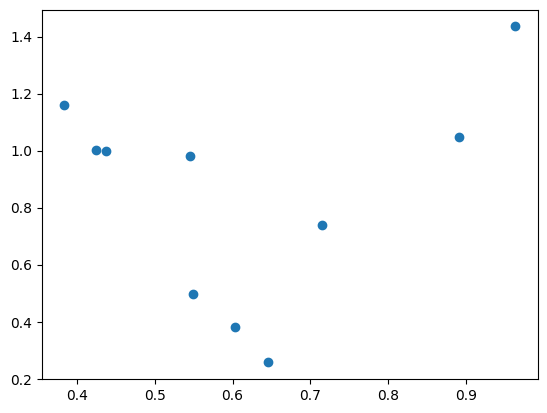

In [7]:
plt.scatter(X_train, y_train) 

In [8]:
# Underlaying function
X_fun = np.linspace(0, 1, 100)
noise_fun = np.ones(100) / 2. * noise_factor
y_fun = fun(X_fun, noise_fun)

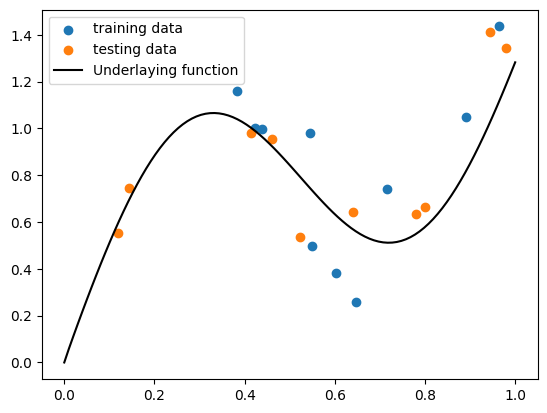

In [14]:
# Plot the data and underlaying function 
plt.scatter(X_train, y_train, label='training data') 
plt.scatter(X_test, y_test, label='testing data') 
plt.plot(X_fun, y_fun, label='Underlaying function', color='black')
plt.legend()

In [15]:
# Fit polynomial model (degree = 10)
poly = PolynomialFeatures(degree=10)
X_train_poly = poly.fit_transform(X_train)

In [16]:
X_train_poly.shape

(10, 11)

In [18]:
model = linear_model.LinearRegression()
model.fit(X_train_poly, y_train)

LinearRegression()

In [31]:
# Evaluate the model - training error 
y_pred = model.predict(X_train_poly)
train_MSE = mean_squared_error(y_train, y_pred)
print(f'Training MSE: {train_MSE}')

Training MSE: 5.429217722705587e-14


In [35]:
# Test error 
X_test_poly = poly.fit_transform(X_test)
y_test_pred = model.predict(X_test_poly)
test_MSE = mean_squared_error(y_test, y_test_pred)
print(f'Testing MSE: {test_MSE}')

Testing MSE: 13867578138.674686


### How well is the model generlized? 

In [40]:
# Helper X, y for plotting 
X_model = np.linspace(0, 1, 100)
X_model_poly = poly.fit_transform(X_model.reshape(-1, 1))
X_model_poly.shape
y_model = model.predict(X_model_poly)

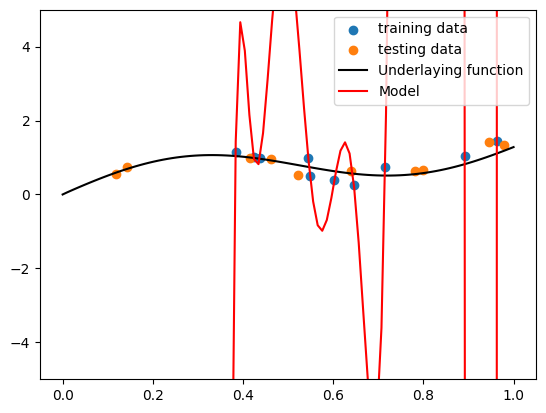

In [48]:
# Plot the model with the data? 
# Plot the data and underlaying function 
plt.scatter(X_train, y_train, label='training data') 
plt.scatter(X_test, y_test, label='testing data') 
plt.plot(X_fun, y_fun, label='Underlaying function', color='black')
plt.plot(X_model, y_model, label='Model', color='red')
plt.ylim((-5, 5))
plt.legend()

### **Exercise 1:** Evaluate the infulence of the data size on model generalization
* Increse the parameter `n_samples` from 10 to 50, 100, 200, and 500
* What is the effect of training data size on its model performance while using model of higher degree than needed? 
* How importan is to have enough samples? 

In [73]:
# set size of the samples
# train model 
# evaluate model  
noise_factor = 0.9
degree = 10
n_samples = 500 # update 
X_train, y_train, X_test, y_test = train_test_data(n_samples, noise_factor)

In [74]:
X_train.shape

(500, 1)

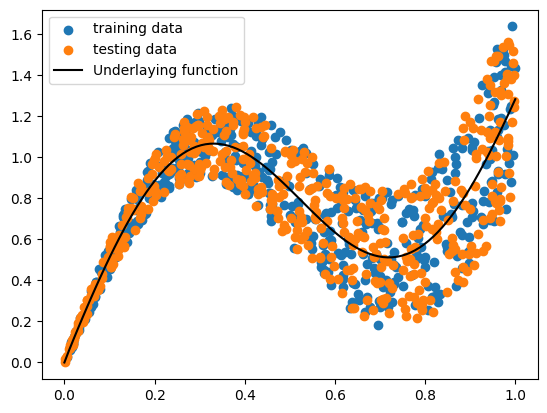

In [75]:
# Underlaying function
X_fun = np.linspace(0, 1, 100)
noise_fun = np.ones(100) / 2. * noise_factor
y_fun = fun(X_fun, noise_fun)
# Plot the data and underlaying function 
plt.scatter(X_train, y_train, label='training data') 
plt.scatter(X_test, y_test, label='testing data') 
plt.plot(X_fun, y_fun, label='Underlaying function', color='black')
plt.legend()

In [76]:
X_train.shape

(500, 1)

In [77]:
# Fit polynomial model 
poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
# fit model 
model = linear_model.LinearRegression()
model.fit(X_train_poly, y_train)
# Evaluate the model - training error 
y_pred = model.predict(X_train_poly)
train_MSE = mean_squared_error(y_train, y_pred)
print(f'Training MSE: {train_MSE}')
# Test error 
X_test_poly = poly.fit_transform(X_test)
y_test_pred = model.predict(X_test_poly)
test_MSE = mean_squared_error(y_test, y_test_pred)
print(f'Testing MSE: {test_MSE}')

Training MSE: 0.02506474464934768
Testing MSE: 0.028958521358639484


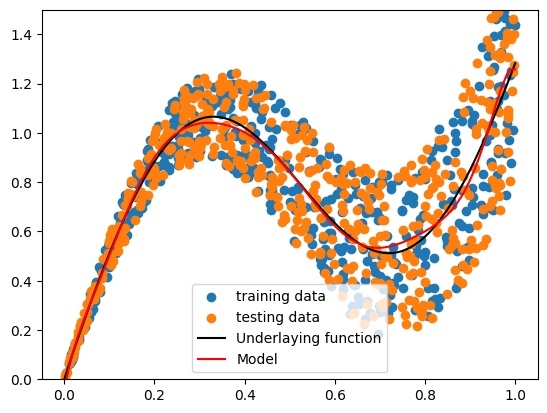

In [78]:
# Plot the model
# Helper X, y for plotting 
X_model = np.linspace(0, 1, 100)
X_model_poly = poly.fit_transform(X_model.reshape(-1, 1))
X_model_poly.shape
y_model = model.predict(X_model_poly)
# Plot the data and underlaying function 
plt.scatter(X_train, y_train, label='training data') 
plt.scatter(X_test, y_test, label='testing data') 
plt.plot(X_fun, y_fun, label='Underlaying function', color='black')
plt.plot(X_model, y_model, label='Model', color='red')
plt.ylim((0, 1.5))
plt.legend()

In [ ]:
# What is the effect of incresing sample size on model generalization? 
# Is there any use of the polynomial model for this use case?

### **Exercise 2:** Evaluate the infulence of noise on the model generalization
* Decrese the noise parameter `noise_factor` from 0.9 to 0.5, and 0.1
* What is the effect of noise in the training data on model generalization? 
* Next, increase  the parameter `n_samples` from to 200 and keep `noise_factor` at 10% = 0.1. How does the model look?  

In [91]:
noise_factor = 0.1
degree = 10
n_samples = 20
X_train, y_train, X_test, y_test = train_test_data(n_samples, noise_factor)

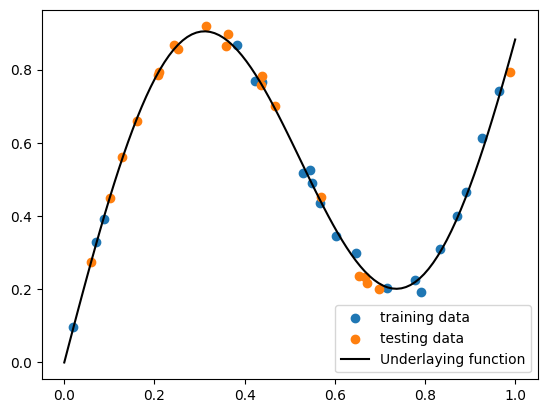

In [92]:
# Underlaying function
X_fun = np.linspace(0, 1, 100)
noise_fun = np.ones(100) / 2. * noise_factor
y_fun = fun(X_fun, noise_fun)
# Plot the data and underlaying function 
plt.scatter(X_train, y_train, label='training data') 
plt.scatter(X_test, y_test, label='testing data') 
plt.plot(X_fun, y_fun, label='Underlaying function', color='black')
plt.legend()

In [93]:
# run the model 
# Fit polynomial model 
poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
# fit model 
model = linear_model.LinearRegression()
model.fit(X_train_poly, y_train)
# Evaluate the model - training error 
y_pred = model.predict(X_train_poly)
train_MSE = mean_squared_error(y_train, y_pred)
print(f'Training MSE: {train_MSE}')
# Test error 
X_test_poly = poly.fit_transform(X_test)
y_test_pred = model.predict(X_test_poly)
test_MSE = mean_squared_error(y_test, y_test_pred)
print(f'Testing MSE: {test_MSE}')

Training MSE: 0.00018735377499041596
Testing MSE: 0.0012679322194894106


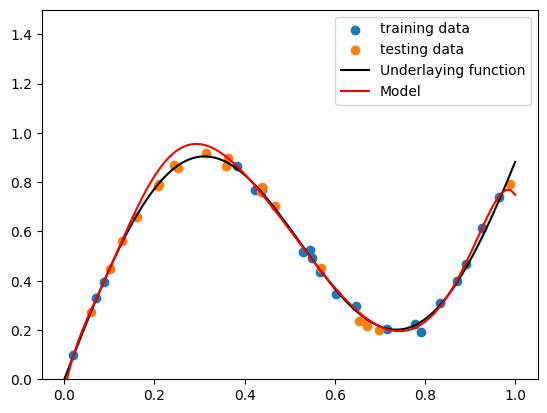

In [94]:
# Plot the model
# Plot the model
# Helper X, y for plotting 
X_model = np.linspace(0, 1, 100)
X_model_poly = poly.fit_transform(X_model.reshape(-1, 1))
X_model_poly.shape
y_model = model.predict(X_model_poly)
# Plot the data and underlaying function 
plt.scatter(X_train, y_train, label='training data') 
plt.scatter(X_test, y_test, label='testing data') 
plt.plot(X_fun, y_fun, label='Underlaying function', color='black')
plt.plot(X_model, y_model, label='Model', color='red')
plt.ylim((0, 1.5))
plt.legend()

In [ ]:
# Evaluate the results 

### **Exercise 3:** Simplify the model for better generalization
* Decrese the degree of polynomial of model`deg` from 10 to reasonable number, so the difference between testing and training model is minimized. 


In [127]:
noise_factor = 0.5
degree = 4
n_samples = 30 
# run the model 
X_train, y_train, X_test, y_test = train_test_data(n_samples, noise_factor)

In [128]:
X_train.shape

(30, 1)

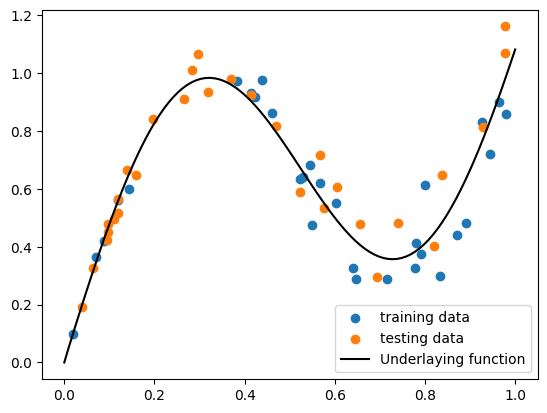

In [129]:
# Underlaying function
X_fun = np.linspace(0, 1, 100)
noise_fun = np.ones(100) / 2. * noise_factor
y_fun = fun(X_fun, noise_fun)
# Plot the data and underlaying function 
plt.scatter(X_train, y_train, label='training data') 
plt.scatter(X_test, y_test, label='testing data') 
plt.plot(X_fun, y_fun, label='Underlaying function', color='black')
plt.legend()

In [130]:
# Fit polynomial model 
poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
# fit model 
model = linear_model.LinearRegression()
model.fit(X_train_poly, y_train)
# Evaluate the model - training error 
y_pred = model.predict(X_train_poly)
train_MSE = mean_squared_error(y_train, y_pred)
print(f'Training MSE: {train_MSE}')
# Test error 
X_test_poly = poly.fit_transform(X_test)
y_test_pred = model.predict(X_test_poly)
test_MSE = mean_squared_error(y_test, y_test_pred)
print(f'Testing MSE: {test_MSE}')

Training MSE: 0.008209055674040738
Testing MSE: 0.00841369870761788


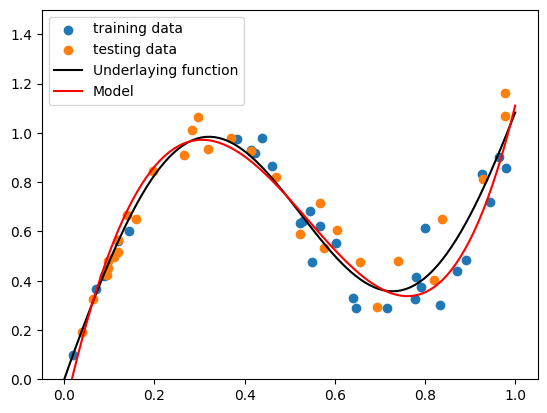

In [131]:
# Plot the model
# Helper X, y for plotting 
X_model = np.linspace(0, 1, 100)
X_model_poly = poly.fit_transform(X_model.reshape(-1, 1))
X_model_poly.shape
y_model = model.predict(X_model_poly)
# Plot the data and underlaying function 
plt.scatter(X_train, y_train, label='training data') 
plt.scatter(X_test, y_test, label='testing data') 
plt.plot(X_fun, y_fun, label='Underlaying function', color='black')
plt.plot(X_model, y_model, label='Model', color='red')
plt.ylim((0, 1.5))
plt.legend()

In [ ]:
# Evaluate the results